<a href="https://colab.research.google.com/github/NandakrishnanR/Kaggle_projects/blob/master/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install xgboost
!pip install opendatasets

In [5]:
import os
import opendatasets as od
import pandas as pd
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
od.download('https://www.kaggle.com/c/rossmann-store-sales')

100%|██████████| 6.99M/6.99M [00:00<00:00, 318MB/s]


Extracting archive ./rossmann-store-sales/rossmann-store-sales.zip to ./rossmann-store-sales


In [6]:
import pandas as pd
train_df = pd.read_csv('/content/rossmann-store-sales/train.csv', low_memory=False)
display(train_df.head())
test_df = pd.read_csv('/content/rossmann-store-sales/test.csv', low_memory=False)
store_df = pd.read_csv('/content/rossmann-store-sales/store.csv', low_memory=False)
sample_df = pd.read_csv('/content/rossmann-store-sales/sample_submission.csv', low_memory=False)



,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


# Feature Engineering


1.   here initialy i merge both tables
2.  find relation where sales=0 has any impact



1.   ignore customer column as it is not in test data
2.   Columns date,compeition and promo have more things to say so either we can merge or find a new relationship for them and create new column













In [7]:
merged_df= pd.merge(train_df, store_df, on='Store')
merged_df.isna().sum()
merged_test_df=pd.merge(test_df,store_df,on='Store')

In [8]:
merged_df.corr(numeric_only=True)

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
Store,1.000000,-0.000008,0.005126,0.024325,-0.000047,0.000058,0.000641,-0.026413,-0.050746,-0.004592,0.008488,0.009865,0.038928
DayOfWeek,-0.000008,1.000000,-0.462125,-0.386445,-0.528963,-0.392925,-0.205388,-0.000025,0.000006,-0.000025,0.000168,0.000174,0.000049
Sales,0.005126,-0.462125,1.000000,0.894711,0.678472,0.452345,0.085124,-0.019229,-0.028257,0.012659,-0.091040,0.059558,-0.021127
Customers,0.024325,-0.386445,0.894711,1.000000,0.616768,0.316169,0.071568,-0.102861,-0.030954,0.008931,-0.150159,0.040531,0.028974
Open,-0.000047,-0.528963,0.678472,0.616768,1.000000,0.295042,0.086171,0.007992,0.001384,0.002771,-0.008309,-0.002430,0.001637
Promo,0.000058,-0.392925,0.452345,0.316169,0.295042,1.000000,0.067483,0.000138,-0.000023,0.000152,-0.000983,-0.001008,-0.000283
SchoolHoliday,0.000641,-0.205388,0.085124,0.071568,0.086171,0.067483,1.000000,-0.003689,-0.000526,0.001520,-0.006909,-0.003133,-0.003682
CompetitionDistance,-0.026413,-0.000025,-0.019229,-0.102861,0.007992,0.000138,-0.003689,1.000000,-0.061624,0.025397,-0.139886,-0.054384,-0.109695
CompetitionOpenSinceMonth,-0.050746,0.000006,-0.028257,-0.030954,0.001384,-0.000023,-0.000526,-0.061624,1.000000,-0.060594,-0.009383,-0.036251,0.050326
CompetitionOpenSinceYear,-0.004592,-0.000025,0.012659,0.008931,0.002771,0.000152,0.001520,0.025397,-0.060594,1.000000,-0.077336,-0.079784,0.012155


In [9]:
merged_df[merged_df["StateHoliday"]!="0"]
(merged_df["Sales"]==0).sum()

np.int64(172871)

In [10]:
zero_sales_df = merged_df[merged_df['Sales'] == 0]
print("Shape of zero_sales_df:", zero_sales_df.shape)
display(zero_sales_df.head())

Shape of zero_sales_df: (172871, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
291,292,5,2015-07-31,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,NaN,NaN,NaN
875,876,5,2015-07-31,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,18.0,2015.0,"Feb,May,Aug,Nov"
1406,292,4,2015-07-30,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,NaN,NaN,NaN
1990,876,4,2015-07-30,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,18.0,2015.0,"Feb,May,Aug,Nov"
2521,292,3,2015-07-29,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,NaN,NaN,NaN


In [11]:
merged_df = merged_df.drop('Customers', axis=1)
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day
merged_df['WeekOfYear'] = merged_df['Date'].dt.isocalendar().week.astype(int)
display(merged_df.head())

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31


In [12]:
def split_date(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df.Date.dt.year
    df['Month'] = df.Date.dt.month
    df['Day'] = df.Date.dt.day
    df['WeekOfYear'] = df.Date.dt.isocalendar().week

split_date(merged_df)
display(merged_df.head())
split_date(merged_test_df)
display(merged_test_df.head())


,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,9,17,38
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,9,17,38
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN,2015,9,17,38
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN,2015,9,17,38
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN,2015,9,17,38


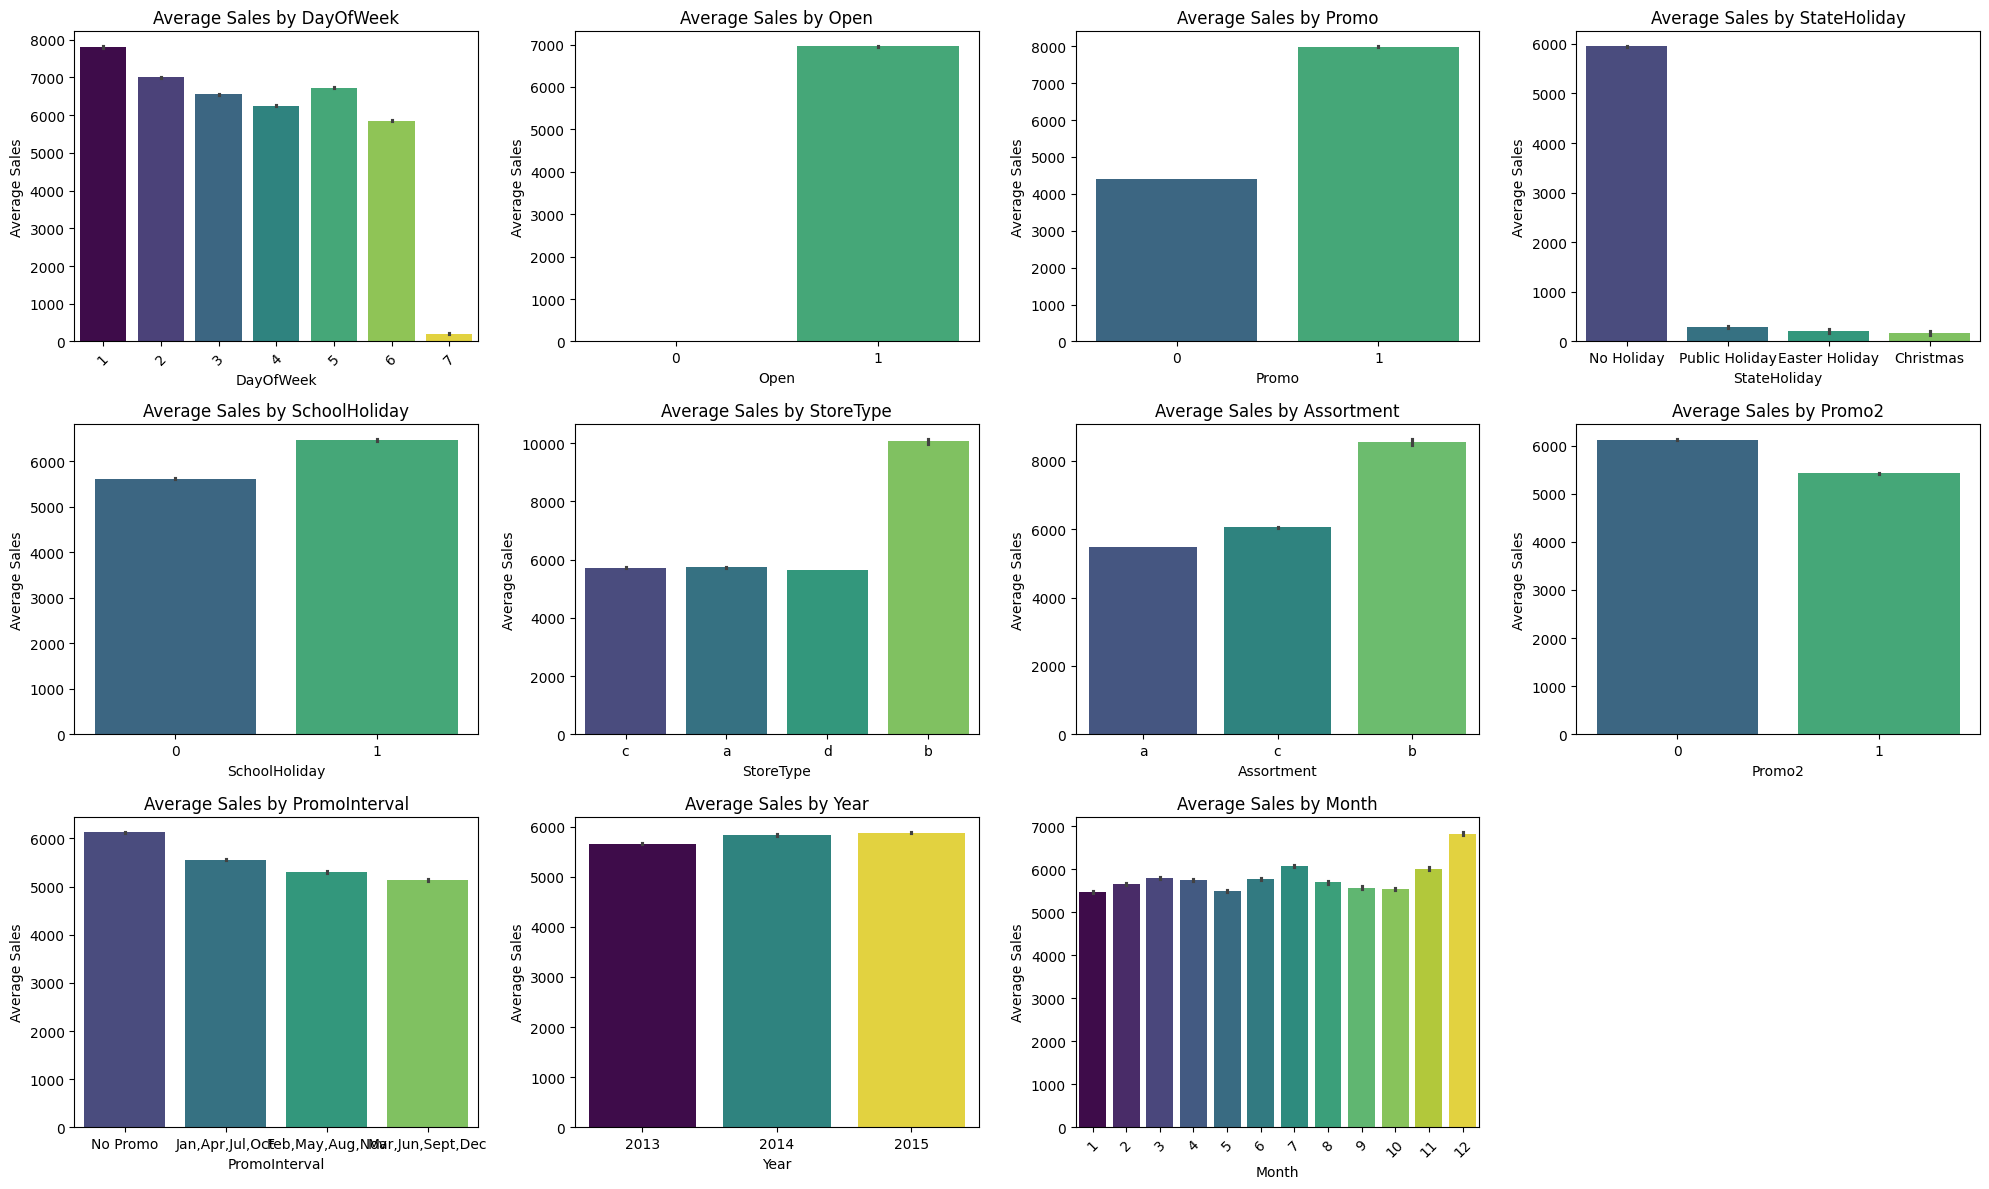

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = [
    'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'Promo2', 'PromoInterval', 'Year', 'Month'
]

# Determine grid dimensions
num_features = len(categorical_features)
num_cols = 4  # Example: 4 columns per row
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))

# Create a copy for plotting to handle NaN values without modifying the original DataFrame
plot_data = merged_df.copy()
plot_data['PromoInterval'] = plot_data['PromoInterval'].fillna('No Promo')
plot_data['StateHoliday'] = plot_data['StateHoliday'].replace({'0': 'No Holiday', 'a': 'Public Holiday', 'b': 'Easter Holiday', 'c': 'Christmas'})

for i, feature in enumerate(categorical_features):
    ax = plt.subplot(num_rows, num_cols, i + 1)
    sns.barplot(data=plot_data, x=feature, y='Sales', ax=ax, palette='viridis', hue=feature, legend=False)
    ax.set_title(f'Average Sales by {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Average Sales')
    if len(plot_data[feature].unique()) > 5: # Rotate labels if too many categories
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

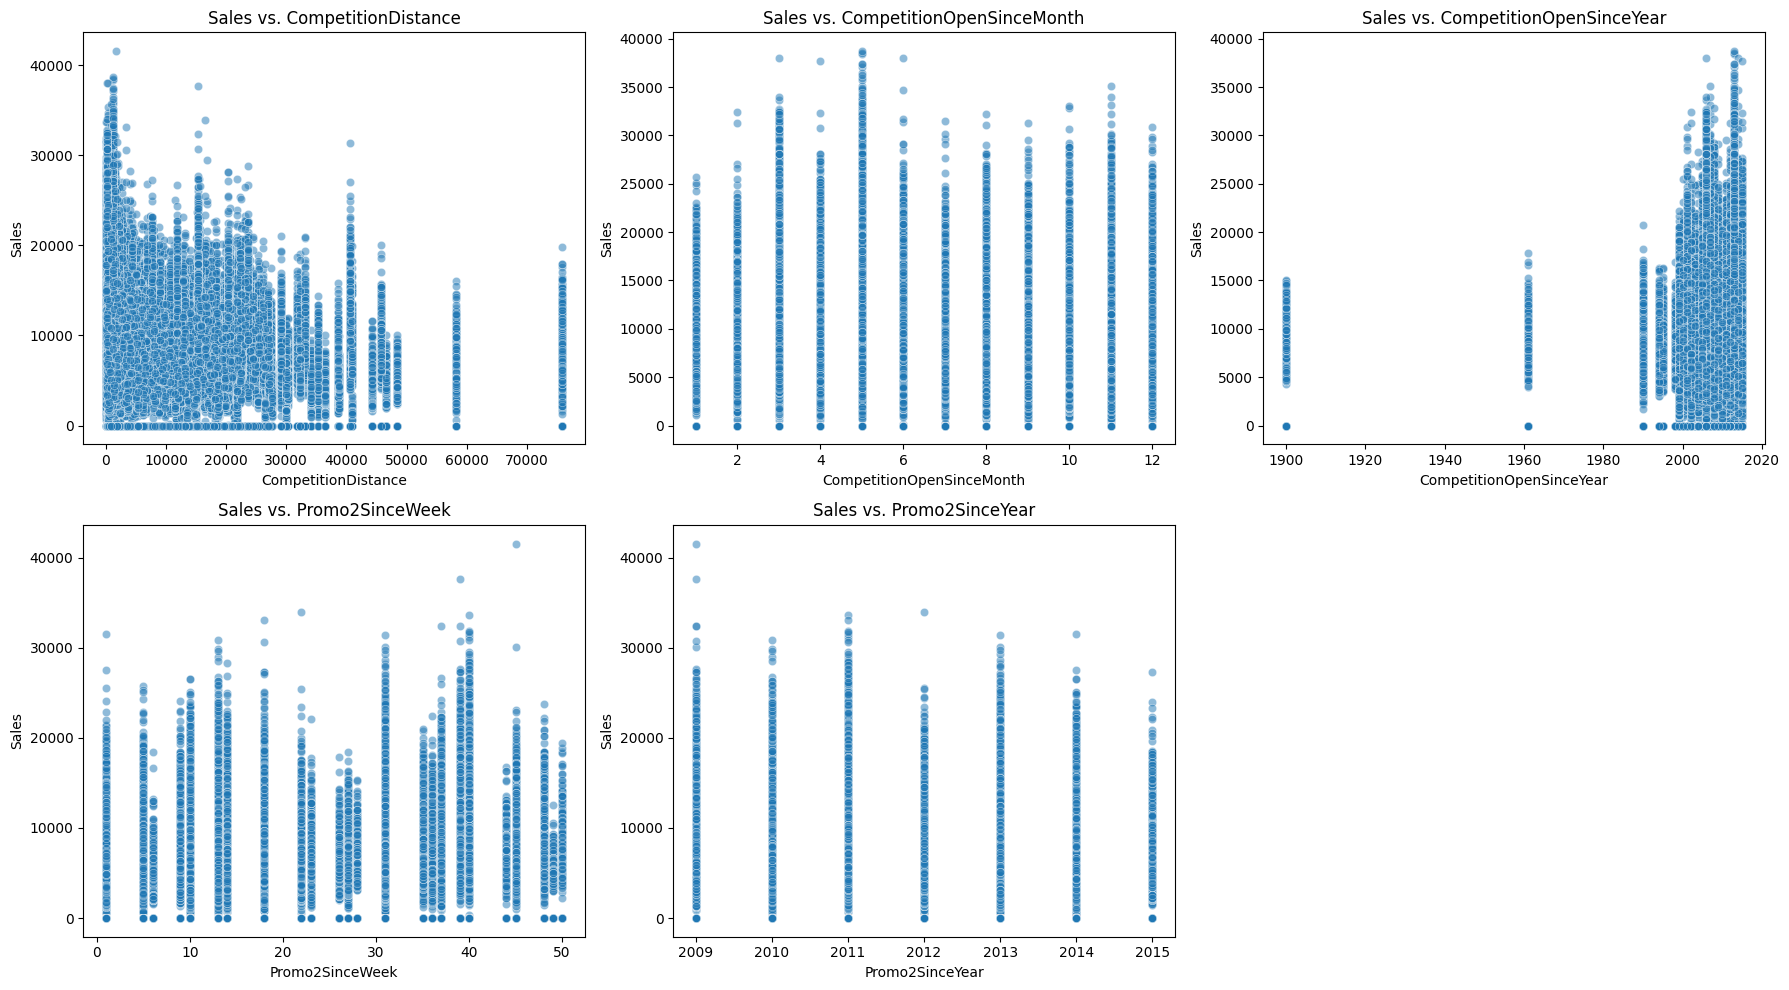

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2SinceWeek', 'Promo2SinceYear'
]

# Determine grid dimensions
num_features = len(numerical_features)
num_cols = 3  # Example: 3 columns per row
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, feature in enumerate(numerical_features):
    ax = plt.subplot(num_rows, num_cols, i + 1)
    # Drop NaN values for the current feature and 'Sales' to ensure clean plots
    plot_data_filtered = merged_df[[feature, 'Sales']].dropna()
    sns.scatterplot(data=plot_data_filtered, x=feature, y='Sales', ax=ax, alpha=0.5)
    ax.set_title(f'Sales vs. {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Sales')

plt.tight_layout()
plt.show()

*#compeition column has more meanings so i extracted them to months calculated form respective date*

In [15]:
def comp_months(df):
    # Calculate raw months difference
    df['CompetitionOpenMonths'] = 12 * (df.Year - df.CompetitionOpenSinceYear) + \
                                  (df.Month - df.CompetitionOpenSinceMonth)

    # Handle cases where competition started after the observation date (negative values)
    # and also fill NaNs for stores with no competition info, by setting them to 0.
    # Using .where() to selectively replace negative values, then fillna.
    df['CompetitionOpenMonths'] = df['CompetitionOpenMonths'].where(df['CompetitionOpenMonths'] >= 0, 0).fillna(0)

# Apply the function to merged_df
comp_months(merged_df)
comp_months(merged_test_df)

print("First 5 rows with new 'CompetitionOpenMonths' column:")
display(merged_df[['Date', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpenMonths']].head())

print("\nNumber of missing values in 'CompetitionOpenMonths':")
print(merged_df['CompetitionOpenMonths'].isnull().sum())

First 5 rows with new 'CompetitionOpenMonths' column:


,Date,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpenMonths
0,2015-07-31,2008.0,9.0,82.0
1,2015-07-31,2007.0,11.0,92.0
2,2015-07-31,2006.0,12.0,103.0
3,2015-07-31,2009.0,9.0,70.0
4,2015-07-31,2015.0,4.0,3.0



Number of missing values in 'CompetitionOpenMonths':
0


In [16]:
#promo2sinceyear and promo2sinceweek can be extracted to a single feature
#here i checked if promo2 is 0,other columnsa re also 0
promo2_is_zero_df = merged_df[merged_df['Promo2'] == 0]

print(f"Number of rows where Promo2 is 0: {len(promo2_is_zero_df)}")
print("\nMissing values in 'Promo2SinceYear' when Promo2 is 0:")
print(promo2_is_zero_df['Promo2SinceYear'].isnull().sum())
print("\nMissing values in 'Promo2SinceWeek' when Promo2 is 0:")
print(promo2_is_zero_df['Promo2SinceWeek'].isnull().sum())

Number of rows where Promo2 is 0: 508031

Missing values in 'Promo2SinceYear' when Promo2 is 0:
508031

Missing values in 'Promo2SinceWeek' when Promo2 is 0:
508031


In [17]:
def calculate_promo2_duration(df):
    # Initialize Promo2DurationMonths to 0 for all rows
    df['Promo2DurationMonths'] = 0

    # Identify rows with active Promo2 participation
    active_promo2_mask = (df['Promo2'] == 1)

    # For active Promo2 rows, construct Promo2StartDate
    # Combine Promo2SinceYear and Promo2SinceWeek into a 'YYYY-WW-1' string
    promo2_start_date_str = df.loc[active_promo2_mask].apply(lambda row: f"{int(row['Promo2SinceYear'])}-{int(row['Promo2SinceWeek'])}-1", axis=1)
    promo2_start_date = pd.to_datetime(promo2_start_date_str, format='%Y-%W-%w')

    # Calculate duration in months for active Promo2 rows
    duration_months = (df.loc[active_promo2_mask, 'Date'].dt.year - promo2_start_date.dt.year) * 12 + \
                      (df.loc[active_promo2_mask, 'Date'].dt.month - promo2_start_date.dt.month)

    # Update Promo2DurationMonths in the DataFrame
    df.loc[active_promo2_mask, 'Promo2DurationMonths'] = duration_months.astype(int)

    # Ensure no negative values are present
    df['Promo2DurationMonths'] = df['Promo2DurationMonths'].apply(lambda x: max(0, x))

# Apply the function to merged_df and merged_test_df
calculate_promo2_duration(merged_df)
calculate_promo2_duration(merged_test_df)

print("First 5 rows of merged_df with 'Promo2DurationMonths' column:")
display(merged_df[['Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'Promo2DurationMonths']].head())

print("First 5 rows of merged_test_df with 'Promo2DurationMonths' column:")
display(merged_test_df[['Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'Promo2DurationMonths']].head())

First 5 rows of merged_df with 'Promo2DurationMonths' column:


,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,Promo2DurationMonths
0,2015-07-31,0,NaN,NaN,0
1,2015-07-31,1,2010.0,13.0,64
2,2015-07-31,1,2011.0,14.0,51
3,2015-07-31,0,NaN,NaN,0
4,2015-07-31,0,NaN,NaN,0


First 5 rows of merged_test_df with 'Promo2DurationMonths' column:


,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,Promo2DurationMonths
0,2015-09-17,0,NaN,NaN,0
1,2015-09-17,1,2011.0,14.0,53
2,2015-09-17,0,NaN,NaN,0
3,2015-09-17,0,NaN,NaN,0
4,2015-09-17,0,NaN,NaN,0


# Input and Target columns

In [18]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month',
       'Day', 'WeekOfYear', 'CompetitionOpenMonths', 'Promo2DurationMonths'],
      dtype='object')

In [19]:
input_col=['Store','DayOfWeek','Open','Promo','StateHoliday','SchoolHoliday','StoreType','Assortment','CompetitionDistance','CompetitionOpenMonths','Promo2','Promo2DurationMonths', 'PromoInterval', 'Year', 'Month','Day', 'WeekOfYear']
target_col=['Sales']

In [20]:
train_input=merged_df[input_col]
train_target=merged_df[target_col]
test_input=merged_test_df[input_col]

# Numerical and categorical

In [21]:
numerical_col = ['Store','DayOfWeek','Open','Promo','SchoolHoliday','CompetitionDistance','CompetitionOpenMonths','Promo2','Promo2DurationMonths','Year','Month','Day','WeekOfYear']
categorical_col = ['StateHoliday','StoreType','Assortment', 'PromoInterval']
train_input[numerical_col].isna().sum()
train_input[categorical_col].isna().sum()

,0
StateHoliday,0
StoreType,0
Assortment,0
PromoInterval,508031


# Imputing

In [22]:
#here if we use anyother imputer it will change the meaning,so i am putting max distance which means less impact or similar to putting a real zero
max_value=train_input.CompetitionDistance.max()
train_input.CompetitionDistance.fillna(max_value,inplace=True)
test_input.CompetitionDistance.fillna(max_value,inplace=True)

/tmp/ipython-input-338558314.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_input.CompetitionDistance.fillna(max_value,inplace=True)
/tmp/ipython-input-338558314.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_input.CompetitionDistance.fillna(max_value,inplace=True)
/tmp/ipython-input-338558314.py:4: FutureWarning: A value

In [23]:
#here cateogircal is column so later in onehot ncoding it splits into 2 meanginfull columns
train_input.PromoInterval = train_input['PromoInterval'].fillna('No Promo')
test_input.PromoInterval = test_input['PromoInterval'].fillna('No Promo')

/tmp/ipython-input-2193380280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_input.PromoInterval = train_input['PromoInterval'].fillna('No Promo')
/tmp/ipython-input-2193380280.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_input.PromoInterval = test_input['PromoInterval'].fillna('No Promo')


In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_input[numerical_col])
train_input[numerical_col]=scaler.transform(train_input[numerical_col])
test_input[numerical_col]=scaler.transform(test_input[numerical_col])

/tmp/ipython-input-2198516973.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_input[numerical_col]=scaler.transform(train_input[numerical_col])
/tmp/ipython-input-2198516973.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_input[numerical_col]=scaler.transform(test_input[numerical_col])


In [25]:
#TO KNOW IF THE CATEGORICAL COLUMN IS CATEGORY ITSELF OR STRING VALUES
train_input[categorical_col].nunique()

,0
StateHoliday,4
StoreType,4
Assortment,3
PromoInterval,4


In [26]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoder.fit(train_input[categorical_col])
encoded_col=encoder.get_feature_names_out(categorical_col)
train_input[encoded_col]=encoder.transform(train_input[categorical_col])
test_input[encoded_col]=encoder.transform(test_input[categorical_col])
train_input[encoded_col]

/tmp/ipython-input-3640422223.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_input[encoded_col]=encoder.transform(train_input[categorical_col])
/tmp/ipython-input-3640422223.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_input[encoded_col]=encoder.transform(train_input[categorical_col])
/tmp/ipython-input-3640422223.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_No Promo
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1017205,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1017206,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1017207,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [27]:
final_features = numerical_col + encoded_col.tolist()

# Select these columns from the preprocessed DataFrames
X = train_input[final_features]
X_test = test_input[final_features]


# Training

In [28]:
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42, n_jobs=-1, n_estimators=20, max_depth=4)
model.fit(X, train_target)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=-1, num_parallel_tree=None, ...)

In [29]:
preds = model.predict(X)
preds

array([7512.2847  , 7221.3267  , 8134.1104  , ...,  -65.476685,
       5008.4785  , -295.83597 ], dtype=float32)

In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(a, b):
    # In newer scikit-learn versions, mean_squared_error always returns MSE.
    # To get RMSE, we calculate MSE and then take its square root.
    return np.sqrt(mean_squared_error(a, b))
rmse(preds,train_target)

np.float64(2233.869065097594)

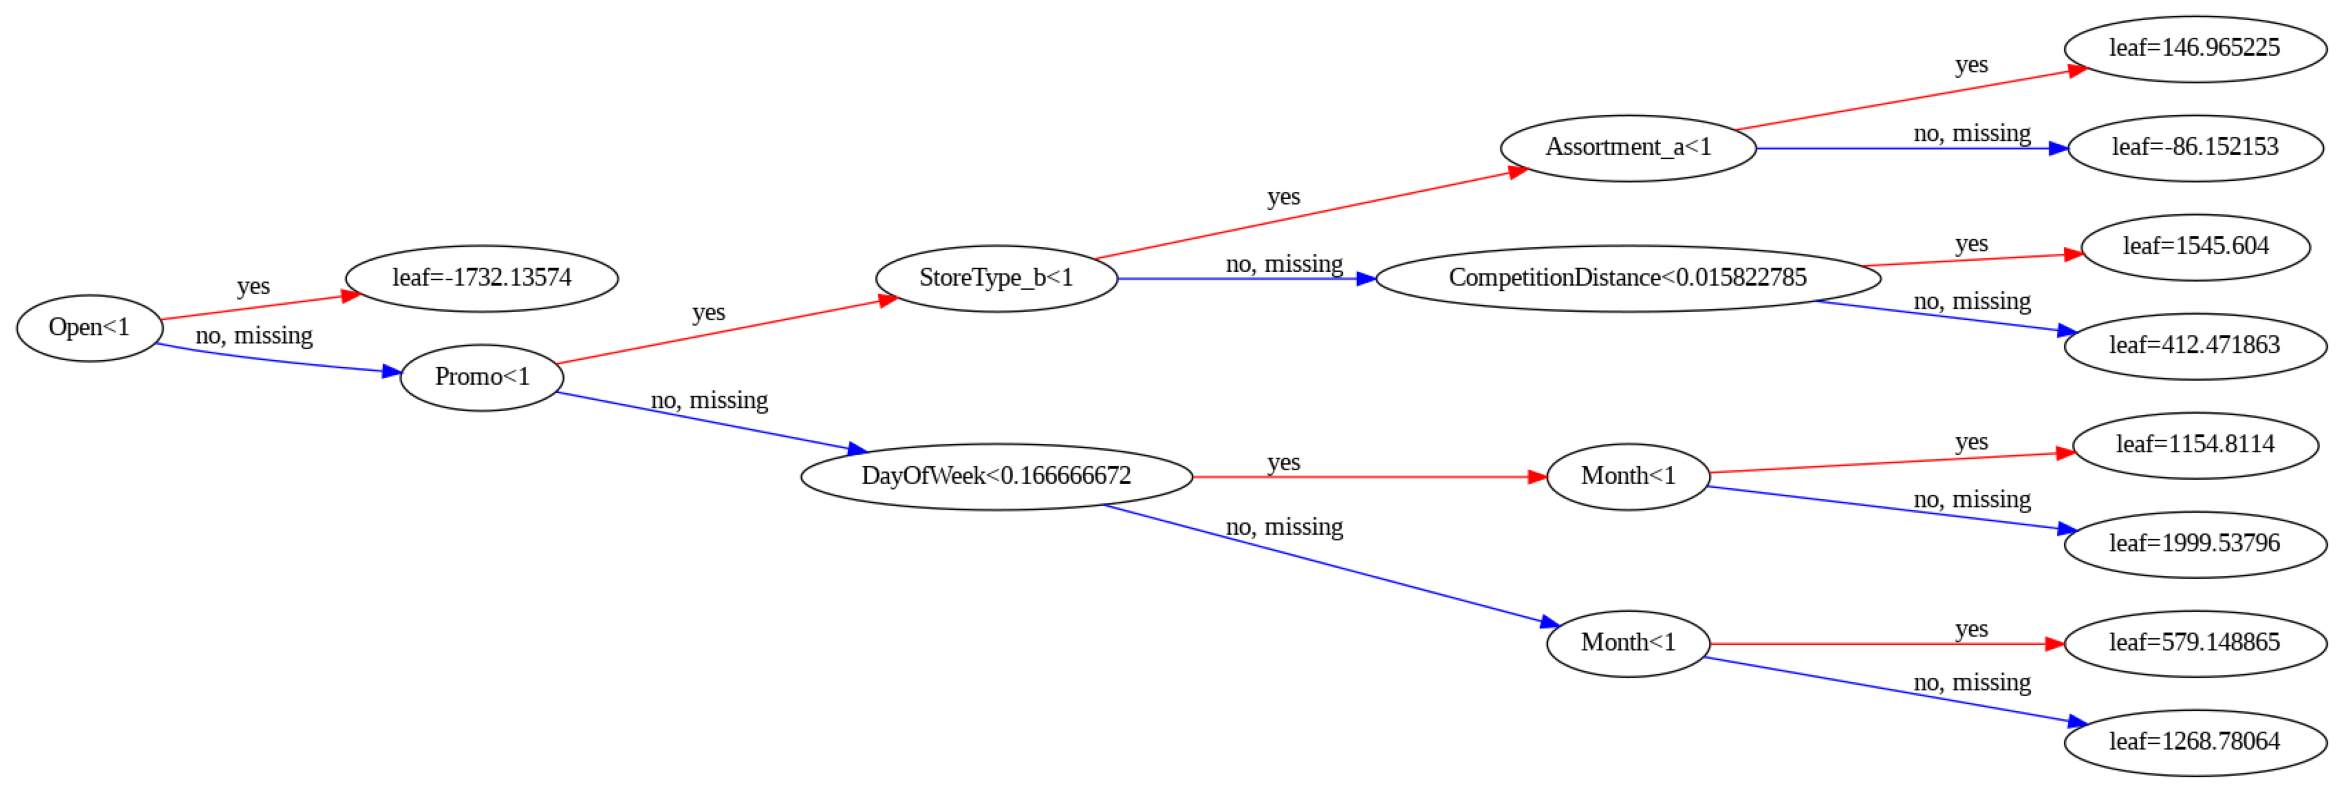

In [33]:
#visualization
import matplotlib.pyplot as plt
from xgboost import plot_tree
from matplotlib.pylab import rcParams
%matplotlib inline

rcParams['figure.figsize'] = 30,30
plot_tree(model, rankdir='LR');

# Feature Importance

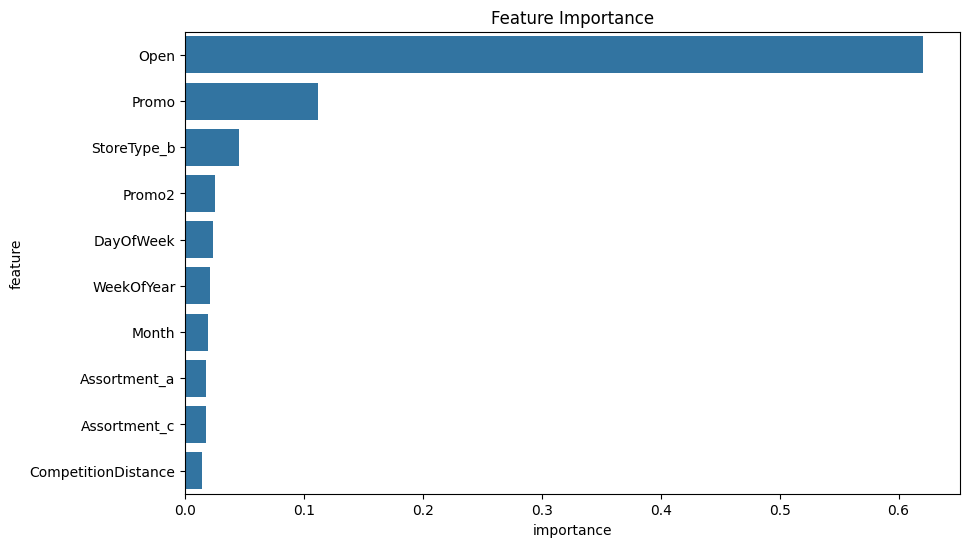

In [35]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
import seaborn as sns
plt.figure(figsize=(10,6))
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

# K FOLD

In [36]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_rmses = []

for fold, (train_index, val_index) in enumerate(kf.split(X, train_target)):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = train_target.iloc[train_index], train_target.iloc[val_index]

    model_fold = XGBRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=4)
    model_fold.fit(X_train_fold, y_train_fold)

    preds_fold = model_fold.predict(X_val_fold)
    current_rmse = rmse(y_val_fold, preds_fold)
    fold_rmses.append(current_rmse)
    print(f"Fold {fold+1} RMSE: {current_rmse:.4f}")

print(f"\nAverage K-Fold RMSE: {np.mean(fold_rmses):.4f}")
print(f"Standard Deviation of K-Fold RMSEs: {np.std(fold_rmses):.4f}")

Fold 1 RMSE: 1721.4546
Fold 2 RMSE: 1720.7576
Fold 3 RMSE: 1709.7979
Fold 4 RMSE: 1722.2109
Fold 5 RMSE: 1704.1974

Average K-Fold RMSE: 1715.6837
Standard Deviation of K-Fold RMSEs: 7.3243


In [ ]:
test_preds = model.predict(X_test)

print("First 10 predictions on X_test:")
display(test_preds[:10])

# Note: Since test_df (and thus X_test) does not have actual 'Sales' values,
# we cannot calculate RMSE directly on this output. These are the final predictions.